# **Capstone Project: A Bi-Objective Evolutionary Approach to Feature Selection for Customer Value Prediction in Fintech**

# *Validation & Business Impact Assessment*

## MBAI 5600G: Applied Integrative Analytics Capstone Project

### Group 7: Brennan Mason & Mohammad Shah

## Environment Setup

In [ ]:
# Specify base path to local directory
BASE_PATH = "/content/drive/Shareddrives/MBAI Capstone S S26 Group 7/"

In [ ]:
!pip install great_tables
!pip install kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451.0/451.0 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 3.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## Data Ingestion

In [ ]:
import numpy as np
import pandas as pd

pd.options.display.float_format = '{:,.5f}'.format

path = BASE_PATH + "p2p-customer-value-prediction/data/processed/cleaned_loans.csv"

loans = pd.read_csv(path)

leaky_cols = [
    "total_pymnt",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "loan_status",
    "last_pymnt_amnt",
    "last_fico_range_low",
    "last_fico_range_high",
    "debt_settlement_flag"
]

loans.drop(columns=leaky_cols, inplace=True)

loans.head()

,funded_amnt,term,int_rate,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,...,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,rar,issue_yr,delinq_recency_bin
0,"7,000.00000",36,0.07890,A,A5,10.00000,MORTGAGE,"69,000.00000",Not Verified,debt_consolidation,...,1.00000,0.00000,"231,893.00000","29,326.00000","9,100.00000","24,693.00000",Cash,"7,126.31286",2015,Never Delinquent
1,"5,000.00000",36,0.06030,A,A1,1.00000,RENT,"37,000.00000",Verified,credit_card,...,0.00000,0.00000,"11,423.00000","1,411.00000","8,200.00000","2,625.00000",Cash,"4,944.31630",2012,Never Delinquent
2,"10,000.00000",36,0.07120,A,A3,3.00000,RENT,"100,000.00000",Source Verified,debt_consolidation,...,0.00000,0.00000,"196,745.00000","143,072.00000","27,500.00000","161,126.00000",Cash,"9,830.12403",2014,Never Delinquent
3,"12,000.00000",36,0.05930,A,A1,NaN,RENT,"60,000.00000",Verified,debt_consolidation,...,0.00000,0.00000,"206,735.00000","12,162.00000","76,700.00000",0.00000,Cash,"11,681.85155",2015,Never Delinquent
4,"6,700.00000",36,0.05320,A,A1,3.00000,MORTGAGE,"69,000.00000",Not Verified,debt_consolidation,...,0.00000,0.00000,"204,505.00000","27,059.00000","52,600.00000","35,900.00000",Cash,"6,753.79570",2017,Never Delinquent


## Data Preprocessing

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline, make_pipeline

# Construct partial preprocessing pipeline for categorical features
cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Construct full preprocessing pipeline
preprocessing_pipe = ColumnTransformer(
    transformers=[
        ("cat", cat_pipe, make_column_selector(dtype_include=object)),
        ("num", SimpleImputer(strategy="median"), make_column_selector(dtype_include=np.number))
    ],
    verbose_feature_names_out=False
)

## Data Partitioning

In [ ]:
target_col = "rar"

# Separate feature matrix and target vector
X = loans.drop(target_col, axis=1)
y = loans[target_col].copy()

## Model Development & Validation

In [ ]:
from sklearn.model_selection import RepeatedKFold

# Define 5x2 CV procedure
cv = RepeatedKFold(n_splits=2, n_repeats=5, random_state=42)

# Specify eval metrics
scoring = ["r2", "neg_mean_absolute_error", "neg_mean_absolute_percentage_error"]

# Define function to compute adjusted R-squared
def compute_adj_r2(r2, n_obs, n_feats):
  """
  Computes the Adjusted R-squared metric.

  Parameters:
  -----------
      - r2 (float): R-squared metric.
      - n_obs (int): Number of observations.
      - n_feats (int): Number of features.

  Returns:
  --------
      - float: Adjusted R-squared metric.
  """
  # Prevent div by zero
  if n_obs <= n_feats + 1:
    return np.nan

  return 1 - (1 - r2) * (n_obs - 1) / (n_obs - n_feats - 1)

# Define function to get clean evaluation summary
def get_eval_summary(scores, X, cond_num, model_name):
  """
  Extracts, calculates, displays, and returns aggregate evaluation metrics from cross-validation.

  Parameters:
  -----------
      - scores (dict): Dictionary of cross-validation scores.
      - X (pd.DataFrame): Full feature matrix used in the experiment.
      - cond_num (int): Experimental condition number.
      - model_name (str): Name of the model/hybrid framework being evaluated.

  Returns:
  --------
      - pd.DataFrame: DataFrame containing evaluation metrics.
  """
  # Initialize eval dict
  eval_dict = {
    "Condition": [],
    "Model": [],
    "R-squared": [],
    "Adjusted R-squared": [],
    "MAE": [],
    "MAPE": [],
    "Fit Time (s)": [],
    "Score Time (s)": [],
    "Feature Count": []
  }

  # Get number of observations in validation set
  n_obs = len(X) / 2

  # Get number of features used by final regressor in pipeline
  if "estimator" in scores:
    try:
      # Extract number of features used during each fold and take average
      fold_feats = [est[-1].n_features_in_ for est in scores["estimator"]]
      n_feats = np.mean(fold_feats)
    except (AttributeError, IndexError):
      n_feats = X.shape[1]
  else:
    n_feats = X.shape[1]

  # Compute aggregate eval metrics
  r2 = round(scores["test_r2"].mean(), 5)
  adj_r2 = round(compute_adj_r2(r2, n_obs, n_feats), 5)
  mae = round(-scores["test_neg_mean_absolute_error"].mean(), 5)
  mape = round(-scores["test_neg_mean_absolute_percentage_error"].mean(), 5)
  fit_time = round(scores["fit_time"].mean(), 5)
  score_time = round(scores["score_time"].mean(), 5)

  # Store results in eval dict
  eval_dict["Condition"].append(cond_num)
  eval_dict["Model"].append(model_name)
  eval_dict["R-squared"].append(r2)
  eval_dict["Adjusted R-squared"].append(adj_r2)
  eval_dict["MAE"].append(mae)
  eval_dict["MAPE"].append(mape)
  eval_dict["Fit Time (s)"].append(fit_time)
  eval_dict["Score Time (s)"].append(score_time)
  eval_dict["Feature Count"].append(n_feats)

  # Display results
  eval_df = pd.DataFrame({
      key: [val[-1]] for key, val in eval_dict.items() if key not in ["Condition", "Model"]
  }).T.reset_index().rename(columns={"index": "Metric", 0: "Value"})

  print(f"=== Results: Condition {cond_num} | {model_name} ===")
  display(eval_df)

  return eval_df

In [ ]:
import xgboost as xgb
from sklearn.model_selection import cross_validate

# Specify most parsimonious feature set (identified via NSGA-II)
parsimonious_feats = [
    "funded_amnt",
    "term",
    "sub_grade",
    "annual_inc",
    "pub_rec",
    "mths_since_recent_inq",
    "num_accts_ever_120_pd",
    "num_op_rev_tl",
    "pub_rec_bankruptcies",
    "tot_hi_cred_lim",
    "issue_yr",
    "delinq_recency_bin"
]

# Specify best hyperparams (identified via HPO)
learning_rate = np.float64(0.049833191601257244)
n_estimators = 274
max_depth = 7

xgb_regr = make_pipeline(
    preprocessing_pipe,
    xgb.XGBRegressor(
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        max_depth=max_depth,
        tree_method="hist",
        n_jobs=-1,
        subsample=0.7,
        random_state=42
    )
)

scores = cross_validate(
    xgb_regr,
    X[parsimonious_feats],
    y,
    cv=cv,
    scoring=scoring,
    return_estimator=True,
    n_jobs=-1
)

eval_df = get_eval_summary(
    scores,
    X[parsimonious_feats],
    cond_num=7,
    model_name="HPO + GB"
)

=== Results: Condition 7 | HPO + GB ===


,Metric,Value
0,R-squared,0.76607
1,Adjusted R-squared,0.76598
2,MAE,"2,606.41801"
3,MAPE,0.39902
4,Fit Time (s),8.90988
5,Score Time (s),1.64148
6,Feature Count,49.00000


> **Notes:**
> * There is a slight discrepancy between the evals reported above and those reported for the final optimized model in M5
> * This misalignment stems from:
>   * **Float truncation** of the hardcoded learning rate
>   * **Algorithmic non-determinism** due to the parallel use of multiple CPU threads in histogram construction (`tree_method="hist"` & `n_jobs=-1`)

In [ ]:
from great_tables import GT, loc, html

# Create clean eval summary table
eval_tbl = (
    GT(eval_df)
    .tab_header(title="Final Model Validation Results")
    .fmt_number(
        columns="Value",
        rows=[0, 1],
        decimals=5
    )
    .fmt_currency(
        columns="Value",
        rows=2,
        currency="USD"
    )
    .fmt_percent(
        columns="Value",
        rows=3
    )
    .fmt_number(
        columns="Value",
        rows=[4, 5],
        decimals=2
    )
    .fmt_integer(
        columns="Value",
        rows=6
    )
    .tab_footnote(
        footnote=html("All evaluation results are averaged across<br>&ensp;10 (5x2) cross-validation folds."),
        locations=loc.column_labels(columns="Value")
    )
    .opt_row_striping()
)

eval_tbl.show()

Final Model Validation Results 
 
 
 Metric 
 Value 1 
 
 
 
 
 R-squared 
 0.76607 
 
 
 Adjusted R-squared 
 0.76598 
 
 
 MAE 
 $2,606.42 
 
 
 MAPE 
 39.90% 
 
 
 Fit Time (s) 
 8.91 
 
 
 Score Time (s) 
 1.64 
 
 
 Feature Count 
 49 
 
 
 1 All evaluation results are averaged across  10 (5x2) cross-validation folds.

In [ ]:
import plotly.graph_objects as go

baseline_feats = 126
baseline_mae = 2611.06

opt_feats = 49
opt_mae = 2606.42

feat_pct_delta = (opt_feats - baseline_feats) / baseline_feats
mae_abs_delta = opt_mae - baseline_mae

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=[baseline_feats, opt_feats],
    y=[baseline_mae, opt_mae],
    mode="markers+text",
    marker=dict(
        size=22,
        color=["darkgrey", "darkorange"],
        line=dict(width=2, color="white")
    ),
    text=[
        f"<b>Baseline Model</b><br>{baseline_feats} Features<br>${baseline_mae:,.2f} MAE",
        f"<b>Optimized Model</b><br>{opt_feats} Features<br>${opt_mae:,.2f} MAE"
    ],
    textposition=["top center", "bottom center"],
    textfont=dict(
        family="Helvetica Neue, sans-serif",
        size=14,
        color=["darkgrey", "darkorange"],
    ),
    showlegend=False
))

fig.add_annotation(
    x=opt_feats + 1.1,
    y=opt_mae,
    ax=baseline_feats - 0.9,
    ay=baseline_mae,
    xref="x",
    yref="y",
    axref="x",
    ayref="y",
    showarrow=True,
    arrowhead=3,
    arrowsize=1.5,
    arrowwidth=3,
    arrowcolor="darkslategrey",
    opacity=0.6
)

fig.add_annotation(
    x=opt_feats + ((baseline_feats - opt_feats) * 0.5),
    y=opt_mae + ((baseline_mae - opt_mae) * 0.95),
    text=f"<b>Optimization Yield:</b><br>•  {-feat_pct_delta:.0%} reduction in dimensionality<br>•  ${-mae_abs_delta:,.2f} reduction in average |error|",
    showarrow=False,
    font=dict(
        family="Helvetica Neue, sans-serif",
        size=14,
        color="darkslategrey"
    ),
    bgcolor="#F8F9FA",
      bordercolor="darkslategrey",
      borderwidth=1,
      borderpad=10,
      align="left"
)

fig.update_layout(
    title=dict(
        text="Complexity vs Predictive Performance",
        font=dict(size=18),
        subtitle=dict(text="<i><span style='color: #A9A9A9;'>Baseline Model</span></i> | <i><span style='color: #FF8C00'>Final Optimized Model</span></i>")
    ),
    xaxis_title="Number of Features",
    yaxis_title="Mean Absolute Error (USD)",
    template="plotly_white",
    font=dict(
        family="Helvetica Neue, sans-serif",
        color="#666666"
    ),
    width=1000,
    height=600,
    margin=dict(t=80, b=60, l=80, r=60)
)

fig.update_xaxes(ticklabelstandoff=10, gridcolor="#F0F0F0", range=[40, 135])
fig.update_yaxes(tickformat="$,.0f", ticklabelstandoff=10, gridcolor="#F0F0F0", range=[2602, 2615.50])

fig.show()

## Robustness & Reliability Analysis

In [ ]:
# Get per-fold eval results
fold_evals_df = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(10)],
    "R-squared": scores["test_r2"],
    "MAE": -scores["test_neg_mean_absolute_error"],
    "MAPE": -scores["test_neg_mean_absolute_percentage_error"]
})

fold_mean = fold_evals_df.mean(numeric_only=True).rename("Mean")
fold_std = fold_evals_df.std(numeric_only=True).rename("Std. Dev.")

agg_evals_df = pd.concat([fold_mean, fold_std], axis=1)
agg_evals_df["Coef. of Var."] = agg_evals_df["Std. Dev."] / agg_evals_df["Mean"]

In [ ]:
fold_evals_tbl = (
    GT(fold_evals_df)
    .tab_header(title="Per-Fold Cross-Validation Results")
    .fmt_number(
        columns="R-squared",
        decimals=5
    )
    .fmt_currency(
        columns="MAE",
        currency="USD"
    )
    .fmt_percent(
        columns="MAPE"
    )
    .opt_row_striping()
)

fold_evals_tbl.show()

Per-Fold Cross-Validation Results 
 
 
 Fold 
 R-squared 
 MAE 
 MAPE 
 
 
 
 
 Fold 1 
 0.76408 
 $2,609.49 
 39.93% 
 
 
 Fold 2 
 0.76824 
 $2,601.48 
 39.85% 
 
 
 Fold 3 
 0.76632 
 $2,604.57 
 39.94% 
 
 
 Fold 4 
 0.76541 
 $2,609.06 
 39.88% 
 
 
 Fold 5 
 0.76759 
 $2,599.58 
 39.90% 
 
 
 Fold 6 
 0.76438 
 $2,617.80 
 39.92% 
 
 
 Fold 7 
 0.76586 
 $2,605.87 
 39.93% 
 
 
 Fold 8 
 0.76651 
 $2,602.81 
 39.81% 
 
 
 Fold 9 
 0.76655 
 $2,616.03 
 39.92% 
 
 
 Fold 10 
 0.76575 
 $2,597.49 
 39.92%

In [ ]:
agg_evals_df.index.name = "Metric"
agg_evals_df.reset_index(inplace=True)

agg_evals_tbl = (
    GT(agg_evals_df)
    .tab_header(title="Aggregate Cross-Validation Results")
    .fmt_number(
        columns=["Mean", "Std. Dev."],
        rows=0,
        decimals=5
    )
    .fmt_currency(
        columns=["Mean", "Std. Dev."],
        rows=1,
        currency="USD"
    )
    .fmt_percent(
        columns=["Mean", "Std. Dev."],
        rows=2
    )
    .fmt_percent(
        columns="Coef. of Var."
    )
    .opt_row_striping()
)

agg_evals_tbl.show()

Aggregate Cross-Validation Results 
 
 
 Metric 
 Mean 
 Std. Dev. 
 Coef. of Var. 
 
 
 
 
 R-squared 
 0.76607 
 0.00129 
 0.17% 
 
 
 MAE 
 $2,606.42 
 $6.71 
 0.26% 
 
 
 MAPE 
 39.90% 
 0.04% 
 0.11%

> **Notes:**
> * The model exhibits exceptional stability across CV folds
> * The coefficient of variation for key eval metrics across CV folds ranges from 0.11% to 0.26%, indicating minimal dispersion around their respective central tendencies

In [ ]:
# ID representative median fold
median_mae = fold_evals_df["MAE"].median()
median_diffs = (fold_evals_df["MAE"] - median_mae).abs()
median_idx = median_diffs.idxmin()
median_fold = fold_evals_df.loc[median_idx, "Fold"]
print(f"Representative median fold: {median_fold}")

Representative median fold: Fold 3


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error

# Reproduce CV splits and extract indices for representative median fold
cv_splits = list(cv.split(X[parsimonious_feats], y))
train_idx, test_idx = cv_splits[median_idx]

# Isolate test set for representative median fold
X_test_rep = X[parsimonious_feats].iloc[test_idx]
y_test_rep = y.iloc[test_idx]

# Extract fitted pipeline components for representative median fold
rep_pipe = scores["estimator"][median_idx]
rep_preprocessor = rep_pipe.steps[0][1]
rep_regr = rep_pipe.steps[1][1]

# Make preds
y_pred_rep = rep_pipe.predict(X_test_rep)

# Recover dropped loan status labels and filter on test indices
loan_status_ser = pd.read_csv(path, usecols=["loan_status"])["loan_status"]
status_test_rep = loan_status_ser.iloc[test_idx]

eval_comp_df = pd.DataFrame({
    "Actual RAR": y_test_rep,
    "Predicted RAR": y_pred_rep,
    "Loan Status": status_test_rep
})

In [ ]:
# Define custom function to compute grouped evals
def compute_subgroup_evals(group):
  return pd.Series({
      "Observation Count": len(group),
      "R-squared": r2_score(group["Actual RAR"], group["Predicted RAR"]),
      "MAE": mean_absolute_error(group["Actual RAR"], group["Predicted RAR"]),
      "MAPE": mean_absolute_percentage_error(group["Actual RAR"], group["Predicted RAR"])
  })

# Compute evals by loan status
status_evals_df = eval_comp_df.groupby("Loan Status").apply(compute_subgroup_evals, include_groups=False).reset_index()

In [ ]:
status_evals_tbl = (
    GT(status_evals_df)
    .tab_header(
        title="Model Performance by Loan Status",
        subtitle="Fully Paid vs Charged Off Loans"
    )
    .fmt_integer(columns="Observation Count")
    .fmt_number(columns="R-squared", decimals=5)
    .fmt_currency(columns="MAE", currency="USD")
    .fmt_percent(columns="MAPE")
    .tab_footnote(
        footnote="Results reported based on Fold 3's test set.",
        locations=loc.title()
    )
    .opt_row_striping()
)

status_evals_tbl.show()

Model Performance by Loan Status 1 
 
 
 Fully Paid vs Charged Off Loans 
 
 
 Loan Status 
 Observation Count 
 R-squared 
 MAE 
 MAPE 
 
 
 
 
 Charged Off 
 25,448 
 −1.26826 
 $6,473.44 
 160.20% 
 
 
 Fully Paid 
 101,716 
 0.92042 
 $1,636.63 
 9.86% 
 
 
 1 Results reported based on Fold 3's test set.

> **Notes:**
> * The model performs significantly worse on charged off loans than it does on fully paid loans
> * The negative $R^2$ score for charged off loans indicates that the model performs much worse than a simple dummy model (i.e., predicting the mean RAR) would on this subset

In [ ]:
import plotly.graph_objects as go

overall_mae = eval_df.loc[eval_df["Metric"] == "MAE", "Value"].values[0]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=status_evals_df["Loan Status"],
    y=status_evals_df["MAE"],
    marker=dict(color="steelblue"),
    text=status_evals_df["MAE"],
    texttemplate="$%{text:,.2f}",
    textposition="inside",
    insidetextanchor="end",
    textfont=dict(color="white", size=14)
))

fig.add_hline(
    y=overall_mae,
    line=dict(color="darkslategrey", dash="dot", width=1.5),
    layer="above",
    annotation_text=f"Overall MAE: ${overall_mae:,.2f}",
    annotation_position="top right",
    annotation_font=dict(color="darkslategrey", size=14)
)

fig.update_layout(
    title="Mean Absolute Error by Loan Status",
    xaxis_title="Loan Status",
    yaxis_title="Mean Absolute Error (USD)",
    template="seaborn",
    font=dict(
        family="Helvetica Neue, sans-serif",
        color="#666666"
    ),
    width=1000,
    height=600
)

fig.update_yaxes(tickformat="$~s",ticklabelstandoff=5)
fig.update_xaxes(ticklabelstandoff=5)

fig.show()

/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




In [ ]:
eval_comp_df.groupby("Loan Status").agg(
    {"Actual RAR": ["mean", "std"]}
)

Actual RAR            
                    mean         std
Loan Status                         
Charged Off  7,486.96716 5,569.42908
Fully Paid  14,977.13724 9,243.04282

In [ ]:
from plotly.subplots import make_subplots

fully_paid_loans = eval_comp_df[eval_comp_df["Loan Status"] == "Fully Paid"]
charged_off_loans = eval_comp_df[eval_comp_df["Loan Status"] == "Charged Off"]

fig = make_subplots(rows=1, cols=2, subplot_titles=("Fully Paid Loans", "Charged Off Loans"))

fig.add_trace(go.Histogram(
    x=fully_paid_loans["Actual RAR"],
    name="Fully Paid",
    marker=dict(color="steelblue"),
    nbinsx=30,
    showlegend=False
), row=1, col=1)

fig.add_trace(go.Histogram(
    x=charged_off_loans["Actual RAR"],
    name="Charged Off",
    marker=dict(color="darkorange"),
    nbinsx=30,
    showlegend=False
), row=1, col=2)

fig.update_layout(
    title="Distribution of Actual RAR by Loan Status",
    xaxis_title="Risk-Adjusted Revenue ($)",
    template="seaborn",
    font=dict(
        family="Helvetica Neue, sans-serif",
        color="#666666"
    ),
    width=1200,
    height=600
)

fig.update_yaxes(title_text="Frequency", tickformat=",.0f", ticklabelstandoff=5, row=1, col=1)
fig.update_yaxes(title_text="Frequency", tickformat=",.0f", ticklabelstandoff=5, row=1, col=2)
fig.update_xaxes(title_text="Risk-Adjusted Revenue (USD)", tickformat="$~s", ticklabelstandoff=5, row=1, col=1)
fig.update_xaxes(title_text="Risk-Adjusted Revenue (USD)", tickformat="$~s", ticklabelstandoff=5, row=1, col=2)

fig.show()

> **Notes:**
> * Although the RAR distributions for fully paid and charged off loans are both positively skewed, the tail for charged off loans is much thinner
> * This indicates that extreme RAR outcomes are much rarer for charged off loans

In [ ]:
# Recover dropped total payment col and filter on test indices
total_pymnt_ser = pd.read_csv(path, usecols=["total_pymnt"])["total_pymnt"]
total_pymnt_test_rep = total_pymnt_ser.iloc[test_idx]
eval_comp_df["Total Payment"] = total_pymnt_test_rep

funded_amnt_test_rep = X_test_rep["funded_amnt"]
eval_comp_df["Funded Amount"] = funded_amnt_test_rep

eval_comp_df["Actual Return"] = eval_comp_df["Total Payment"] - eval_comp_df["Funded Amount"]

eval_comp_df.groupby("Loan Status").agg(
    {"Actual Return": ["mean", "std"]}
)

Actual Return            
                     mean         std
Loan Status                          
Charged Off  -7,286.50414 6,658.79663
Fully Paid    2,330.72932 2,557.00661

In [ ]:
fully_paid_loans = eval_comp_df[eval_comp_df["Loan Status"] == "Fully Paid"]
charged_off_loans = eval_comp_df[eval_comp_df["Loan Status"] == "Charged Off"]

fig = make_subplots(rows=1, cols=2, subplot_titles=("Fully Paid Loans", "Charged Off Loans"))

fig.add_trace(go.Histogram(
    x=fully_paid_loans["Actual Return"],
    name="Fully Paid",
    marker=dict(color="steelblue"),
    nbinsx=50,
    showlegend=False
), row=1, col=1)

fig.add_trace(go.Histogram(
    x=charged_off_loans["Actual Return"],
    name="Charged Off",
    marker=dict(color="darkorange"),
    nbinsx=50,
    showlegend=False
), row=1, col=2)

fig.update_layout(
    title="Distribution of Actual Return by Loan Status",
    xaxis_title="Realized Return ($)",
    template="seaborn",
    font=dict(
        family="Helvetica Neue, sans-serif",
        color="#666666"
    ),
    width=1200,
    height=600
)

fig.update_yaxes(title_text="Frequency", tickformat=",.0f", ticklabelstandoff=5, row=1, col=1)
fig.update_yaxes(title_text="Frequency", tickformat=",.0f", ticklabelstandoff=5, row=1, col=2)
fig.update_xaxes(title_text="Realized Return (USD)", tickformat="$~s", ticklabelstandoff=5, row=1, col=1)
fig.update_xaxes(title_text="Realized Return (USD)", tickformat="$~s", ticklabelstandoff=5, row=1, col=2)

fig.show()

> **Notes:**
> * When considering loan profitability in terms of nominal dollars (i.e., *Total Recieved Payment* - *Funded Amount*), the stark business impact of charge-offs becomes clear
> * As expected, fully paid loans tend to drive profits, whereas charged off loans tend to yield losses
> * Based on the above, perhaps LC should focus instead on predicting the probability of default (PD) to screen out high-risk applicants and decrease its charge-off rate

In [ ]:
yr_test_rep = X_test_rep["issue_yr"]
eval_comp_df["Issue Year"] = yr_test_rep

# Compute evals by issue year
yr_evals_df = eval_comp_df.groupby("Issue Year").apply(compute_subgroup_evals, include_groups=False).reset_index()
yr_evals_df.sort_values(by="Issue Year", ascending=True, inplace=True)

In [ ]:
yr_evals_tbl = (
    GT(yr_evals_df)
    .tab_header(title="Model Performance by Issue Year")
    .fmt_integer(columns="Observation Count")
    .fmt_number(columns="R-squared", decimals=5)
    .fmt_currency(columns="MAE", currency="USD")
    .fmt_percent(columns="MAPE")
    .tab_footnote(
        footnote="Results reported based on Fold 3's test set.",
        locations=loc.title()
    )
    .opt_row_striping()
)

yr_evals_tbl.show()

Model Performance by Issue Year 1 
 
 
 Issue Year 
 Observation Count 
 R-squared 
 MAE 
 MAPE 
 
 
 
 
 2012 
 2,528 
 0.83469 
 $1,901.22 
 27.80% 
 
 
 2013 
 13,468 
 0.83360 
 $1,888.47 
 23.96% 
 
 
 2014 
 22,376 
 0.82148 
 $2,115.71 
 27.14% 
 
 
 2015 
 37,151 
 0.78331 
 $2,418.28 
 33.03% 
 
 
 2016 
 29,169 
 0.75107 
 $2,898.88 
 43.06% 
 
 
 2017 
 16,905 
 0.68471 
 $3,518.69 
 58.22% 
 
 
 2018 
 5,567 
 0.65526 
 $3,546.64 
 109.85% 
 
 
 1 Results reported based on Fold 3's test set.

In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=yr_evals_df["Issue Year"],
    y=yr_evals_df["MAE"],
    mode="lines+markers",
    marker=dict(color="steelblue", size=10),
    line=dict(color="steelblue")
))

fig.add_hline(
    y=overall_mae,
    line=dict(color="darkslategrey", dash="dot", width=1.5),
    layer="above",
    annotation_text=f"Overall MAE: ${overall_mae:,.2f}",
    annotation_position="top right",
    annotation_font=dict(color="darkslategrey", size=14)
)

fig.update_layout(
    title="Mean Absolute Error by Issue Year",
    xaxis_title="Issue Year",
    yaxis_title="Mean Absolute Error (USD)",
    template="seaborn",
    font=dict(
        family="Helvetica Neue, sans-serif",
        color="#666666"
    ),
    width=1000,
    height=600
)

fig.update_yaxes(tickformat="$,.0f",ticklabelstandoff=5, range=[1000, 3800])
fig.update_xaxes(ticklabelstandoff=5)

fig.show()

> **Notes:**
> * The model's performance is generally getting worse over time

In [ ]:
charge_offs_by_yr = eval_comp_df.groupby(["Issue Year", "Loan Status"])["Loan Status"].count()
charge_offs_by_yr = charge_offs_by_yr.to_frame().rename(columns={"Loan Status": "Count"}).unstack().fillna(0)
charge_offs_by_yr = charge_offs_by_yr["Count"][["Charged Off", "Fully Paid"]]
charge_offs_by_yr["Charge-Off Rate"] = charge_offs_by_yr["Charged Off"] / (charge_offs_by_yr["Charged Off"] + charge_offs_by_yr["Fully Paid"])
charge_offs_by_yr.reset_index(inplace=True)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=charge_offs_by_yr["Issue Year"],
    y=charge_offs_by_yr["Charge-Off Rate"],
    mode="lines+markers",
    marker=dict(color="steelblue", size=10),
    line=dict(color="steelblue")
))

fig.update_layout(
    title="Charge-Off Rate by Issue Year",
    xaxis_title="Issue Year",
    yaxis_title="Charge-Off Rate",
    template="seaborn",
    font=dict(
        family="Helvetica Neue, sans-serif",
        color="#666666"
    ),
    width=1000,
    height=600
)

fig.update_yaxes(tickformat=".0%",ticklabelstandoff=5, range=[0.10, 0.25])
fig.update_xaxes(ticklabelstandoff=5)

fig.show()

In [ ]:
from scipy.stats import pearsonr

merged_df = pd.merge(
    yr_evals_df[["Issue Year", "MAE"]],
    charge_offs_by_yr[["Issue Year", "Charge-Off Rate"]],
    on="Issue Year",
    how="inner"
)

# Filter for 2013-16 temporal window
trend_window = merged_df[merged_df["Issue Year"].isin([2013, 2014, 2015, 2016])]

# Compute correlation
r_stat, p_val = pearsonr(trend_window["MAE"], trend_window["Charge-Off Rate"])

print(f"Pearson's r: {r_stat:.4f}")
print(f"p-value: {p_val:.4f}")

Pearson's r: 0.9867
p-value: 0.0133


> **Notes:**
> * The degradation in performance over time may in part be driven by the volatility of LC's charge-off rate over time
> * From 2013 to 2016, the MAE and the charge-off rate trend upwards in tandem ($r$ = ~0.99), although this pattern is broken by the charge-off rate's reversal in 2017 and subsequent precipitous drop in 2018

## Error Analysis

In [ ]:
import plotly.graph_objects as go

# Compute residuals
eval_comp_df["Error"] = eval_comp_df["Actual RAR"] - eval_comp_df["Predicted RAR"]
eval_comp_df["Absolute Error"] = eval_comp_df["Error"].abs()

# Merge features
full_eval_df = pd.concat([eval_comp_df, X_test_rep], axis=1)

# Construct histogram of residual distribution
fig = go.Figure()

fig.add_trace(go.Histogram(
    x=eval_comp_df["Error"],
    marker=dict(color="steelblue"),
    nbinsx=40,
    showlegend=False
))

fig.update_layout(
    title="Distribution of Residuals",
    xaxis_title="Residual (USD)",
    yaxis_title="Frequency",
    template="seaborn",
    font=dict(
        family="Helvetica Neue, sans-serif",
        color="#666666"
    ),
    width=1000,
    height=600
)

fig.update_yaxes(tickformat=",.0f", ticklabelstandoff=5)
fig.update_xaxes(tickformat="$~s", ticklabelstandoff=5)

fig.show()

In [ ]:
eval_comp_df["Error"].describe().round(2)

,Error
count,"127,164.00000"
mean,14.26000
std,"4,417.85000"
min,"-39,336.08000"
25%,43.12000
50%,616.55000
75%,"1,656.97000"
max,"26,590.96000"


In [ ]:
from scipy.stats import normaltest

# Check for normality
stat, p_val = normaltest(eval_comp_df["Error"])

print(f"p-value: {p_val:.4f}")

alpha = 0.05
if p_val > alpha:
  print("Sample looks Gaussian (fail to reject H0)")
else:
  print("Sample does not look Gaussian (reject H0)")

p-value: 0.0000
Sample does not look Gaussian (reject H0)


In [ ]:
eval_comp_df["Error"].skew()

np.float64(-1.9554892064055014)

In [ ]:
# Sample observations for scatter plots
n_samples = 5000
plot_df = eval_comp_df.sample(n=n_samples, random_state=42)

# Get points for line to represent perfect preds
x_vals = [eval_comp_df["Actual RAR"].min(), eval_comp_df["Actual RAR"].max()]
y_vals = x_vals

# Construct actual vs predicted plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=plot_df["Actual RAR"],
    y=plot_df["Predicted RAR"],
    mode="markers",
    marker=dict(
        color=plot_df["Absolute Error"],  # Colour points based on abs error
        colorscale="viridis",
        showscale=True,
        colorbar=dict(
            title="Absolute Error (USD)",
            tickformat="$~s",
            thickness=15
        ),
        opacity=0.6,
        size=6
    ),
    showlegend=False,
    name="Observed Predictions"
))

fig.add_trace(go.Scatter(
    x=x_vals,
    y=y_vals,
    mode="lines",
    line=dict(
        color="#D55E00",
        dash="dot",
        width=3
    ),
    showlegend=False,
    name="Perfect Predictions"
))

fig.update_layout(
    title=dict(
        text="Observed vs Predicted RAR",
        subtitle=dict(text=f"Sampled <i>n</i> = {n_samples:,}")
    ),
    xaxis_title="Observed RAR (USD)",
    yaxis_title="Predicted RAR (USD)",
    template="plotly_white",
    font=dict(
        family="Helvetica Neue, sans-serif",
        color="#666666"
    ),
    width=900,
    height=600,
    margin=dict(t=80, b=50, l=50, r=20)
)

fig.update_yaxes(tickformat="$~s", ticklabelstandoff=5, gridcolor="#E5E5E5")
fig.update_xaxes(tickformat="$~s", ticklabelstandoff=5, gridcolor="#E5E5E5")

fig.show()

> **Notes:**
> * Points are clustered densely along the underside of the perfect predictions line, indicating that slight underestimation is exceedingly common
> * As the observed RAR increases, the predominant failure mode shifts from overestimation to underestimation, though the former results in more severe errors than the latter

In [ ]:
# Get points for line to represent perfect preds
x_vals = [eval_comp_df["Predicted RAR"].min(), eval_comp_df["Predicted RAR"].max()]
y_vals = [0, 0]

# Construct residuals vs predicted plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=plot_df["Predicted RAR"],
    y=plot_df["Error"],
    mode="markers",
    marker=dict(
        color="steelblue",
        opacity=0.6,
        size=6
    ),
    showlegend=False,
    name="Observed Predictions"
))

fig.add_trace(go.Scatter(
    x=x_vals,
    y=y_vals,
    mode="lines",
    line=dict(
        color="#D55E00",
        dash="dot",
        width=3
    ),
    showlegend=False,
    name="Perfect Predictions"
))

fig.update_layout(
    title=dict(
        text="Residuals vs Predicted RAR",
        subtitle=dict(text=f"Sampled <i>n</i> = {n_samples:,}")
    ),
    xaxis_title="Predicted RAR (USD)",
    yaxis_title="Residual (USD)",
    template="plotly_white",
    font=dict(
        family="Helvetica Neue, sans-serif",
        color="#666666"
    ),
    width=900,
    height=600,
    margin=dict(t=80, b=50, l=50, r=20)
)

fig.update_yaxes(tickformat="$~s", ticklabelstandoff=5, gridcolor="#E5E5E5")
fig.update_xaxes(tickformat="$~s", ticklabelstandoff=5, gridcolor="#E5E5E5")

fig.show()

> **Notes:**
> * As the predicted RAR increases, the spread of the residuals also increase
> * This funnel shape indicates heteroscedasticity

In [ ]:
# Isolate top 5% worst predictions
pct_95 = full_eval_df["Absolute Error"].quantile(0.95)
worst_preds = full_eval_df[full_eval_df["Absolute Error"] >= pct_95]

print("Status Breakdown - Top 5% Worst Predictions:")
display(worst_preds["Loan Status"].value_counts(normalize=True).sort_index())

print("\nStatus Breakdown - Overall:")
display(full_eval_df["Loan Status"].value_counts(normalize=True).sort_index())

print("\nSubgrade Breakdown (Top 10) - Top 5% Worst Predictions:")
display(worst_preds["sub_grade"].value_counts(normalize=True).sort_values(ascending=False).head(10))

print("\nSubgrade Breakdown (Top 10) - Overall:")
display(full_eval_df["sub_grade"].value_counts(normalize=True).sort_values(ascending=False).head(10))

print("\nDescriptive Stats - Top 5% Worst Predictions:")
display(worst_preds[parsimonious_feats].describe())

print("\nDescriptive Stats - Overall:")
display(full_eval_df[parsimonious_feats].describe())

Status Breakdown - Top 5% Worst Predictions:


,proportion
Loan Status,
Charged Off,0.84793
Fully Paid,0.15207



Status Breakdown - Overall:


,proportion
Loan Status,
Charged Off,0.20012
Fully Paid,0.79988



Subgrade Breakdown (Top 10) - Top 5% Worst Predictions:


...

,proportion
sub_grade,
C1,0.06452
B4,0.06177
B5,0.06125
B3,0.05942
C2,0.05833
C3,0.05731
C4,0.05707
B2,0.05531
B1,0.05332



Descriptive Stats - Top 5% Worst Predictions:


,funded_amnt,term,annual_inc,pub_rec,mths_since_recent_inq,num_accts_ever_120_pd,num_op_rev_tl,pub_rec_bankruptcies,tot_hi_cred_lim,issue_yr
count,"6,359.00000","6,359.00000","6,359.00000","6,359.00000","5,939.00000","6,359.00000","6,359.00000","6,359.00000","6,359.00000","6,359.00000"
mean,"26,725.81381",51.02500,"97,773.36619",0.20176,5.86984,0.50008,9.17361,0.11700,"219,462.10002","2,015.64586"
std,"6,874.67097",11.61338,"63,423.09317",0.58504,5.56798,1.28201,5.11335,0.35360,"190,378.53561",1.38184
min,"11,000.00000",36.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,300.00000,"2,012.00000"
25%,"20,500.00000",36.00000,"65,000.00000",0.00000,1.00000,0.00000,6.00000,0.00000,"78,617.50000","2,015.00000"
50%,"26,000.00000",60.00000,"85,000.00000",0.00000,4.00000,0.00000,8.00000,0.00000,"164,018.00000","2,016.00000"
75%,"33,375.00000",60.00000,"112,000.00000",0.00000,9.00000,0.00000,12.00000,0.00000,"314,919.50000","2,017.00000"
max,"40,000.00000",60.00000,"2,200,000.00000",12.00000,25.00000,26.00000,47.00000,4.00000,"2,546,318.00000","2,018.00000"



Descriptive Stats - Overall:


,funded_amnt,term,annual_inc,pub_rec,mths_since_recent_inq,num_accts_ever_120_pd,num_op_rev_tl,pub_rec_bankruptcies,tot_hi_cred_lim,issue_yr
count,"127,164.00000","127,164.00000","127,164.00000","127,164.00000","114,820.00000","127,164.00000","127,164.00000","127,164.00000","127,164.00000","127,164.00000"
mean,"14,582.57781",41.81334,"76,839.81983",0.22357,6.72475,0.50701,8.26860,0.13905,"175,243.74001","2,015.17917"
std,"8,748.23398",10.28232,"64,709.43672",0.65909,5.84434,1.31660,4.52722,0.38069,"177,263.79870",1.37898
min,"1,000.00000",36.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,200.00000,"2,012.00000"
25%,"8,000.00000",36.00000,"46,000.00000",0.00000,2.00000,0.00000,5.00000,0.00000,"49,819.00000","2,014.00000"
50%,"12,000.00000",36.00000,"65,000.00000",0.00000,5.00000,0.00000,7.00000,0.00000,"113,363.50000","2,015.00000"
75%,"20,000.00000",36.00000,"91,000.00000",0.00000,10.00000,0.00000,10.00000,0.00000,"253,747.00000","2,016.00000"
max,"40,000.00000",60.00000,"7,200,000.00000",86.00000,25.00000,33.00000,71.00000,8.00000,"4,460,960.00000","2,018.00000"


> **Notes:**
> * Among the top 5% worst predictions, the charge-off rate is ~85%, whereas the overall charge-off rate is only ~20%
> * Various C & D subgrades are most prevalent among the top 5% worst predictions, whereas the overall breakdown leans toward B & C grades
> * The average funded amount among the top 5% worst predictions is ~83% higher than the overall average funded amount
> The top 5% worst predictions lean more heavily toward 60-month loans than the overall dataset

## SHAP Analysis

In [ ]:
import shap

# Transform data for SHAP
X_tr = rep_preprocessor.transform(X_test_rep)

# Compute SHAP values
explainer = shap.TreeExplainer(rep_regr)
shap_values = explainer(X_tr)

# Get feature names for viz
feat_names = rep_preprocessor.get_feature_names_out()
shap_values.feature_names = list(feat_names)

In [ ]:
import random

# Sample for plotting
sample_idx = random.sample(range(len(shap_values)), 5000)
shap_values_sample = shap_values[sample_idx]

### Global Explainability Analysis

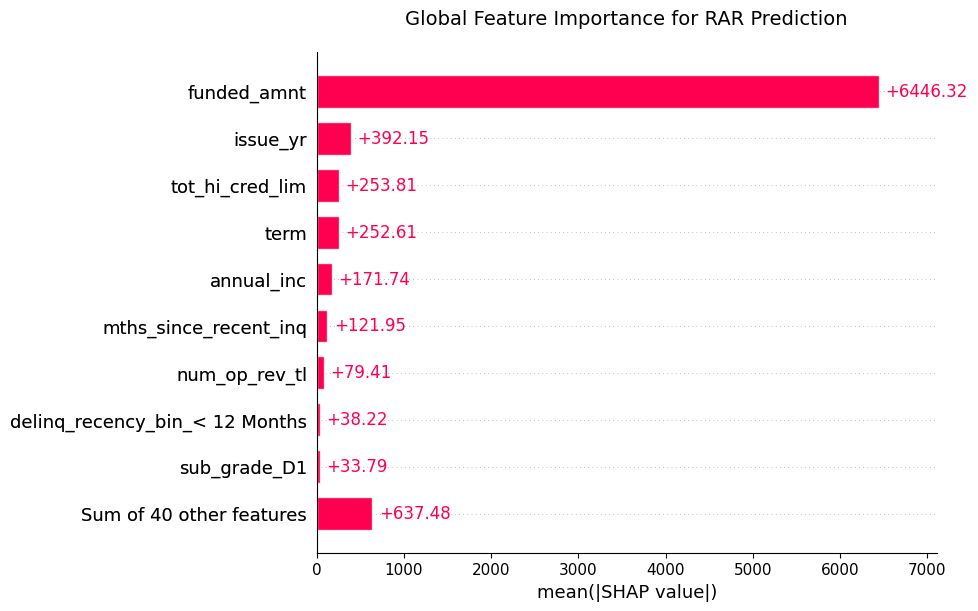

In [ ]:
import matplotlib.pyplot as plt

dir = BASE_PATH + "p2p-customer-value-prediction/reports/figures/"

plt.figure()
shap.plots.bar(shap_values, show=False)

plt.title("Global Feature Importance for RAR Prediction", pad=20, fontsize=14)
plt.savefig(dir + "shap_global_bar.png", dpi=300, bbox_inches="tight")
plt.show()

> **Notes:**
> * As in the gain-based global feature importance from M5, `funded_amnt` remains the most impactful predictor of RAR by a wide margin
> * `issue_yr` and `term` also remain among the dominant determinants of RAR

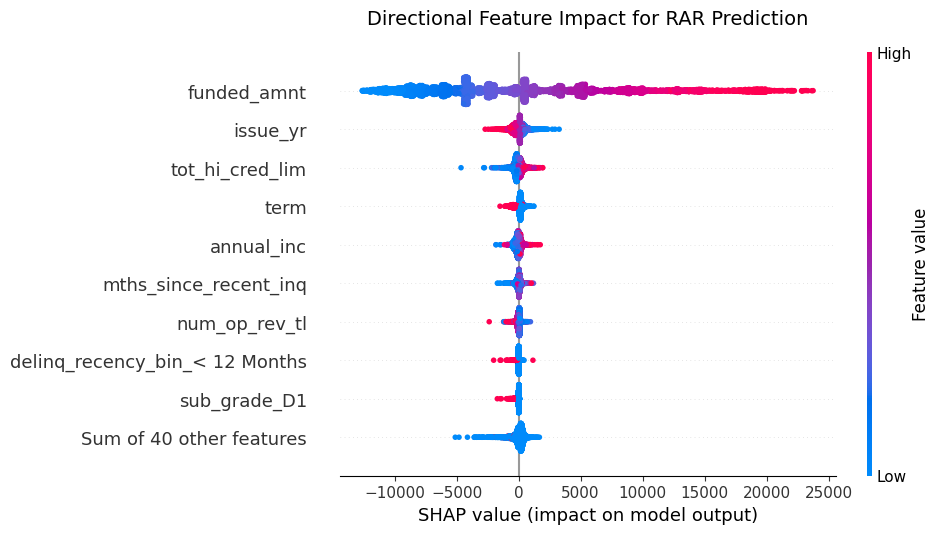

In [ ]:
plt.figure()
shap.plots.beeswarm(shap_values_sample, show=False)

plt.title("Directional Feature Impact for RAR Prediction", pad=20, fontsize=14)
plt.savefig(dir + "shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

> **Notes:**
> * Logically, higher funded amounts tend to drive RAR predictions up and vice versa
> * Later years of issuance tend to drive RAR predictions down and vice versa
> * Longer terms tend to drive RAR predictions down and vice versa
> * Higher credit limits tend to drive RAR predictions up and vice versa (perhaps because more creditworthy borrowers often are granted more credit)
> * Higher annual income tends to drive RAR predictions up
> * Delinquency within the last 12 months tends to drive RAR predictions down

### Sensitivity Analysis

<Figure size 640x480 with 0 Axes>

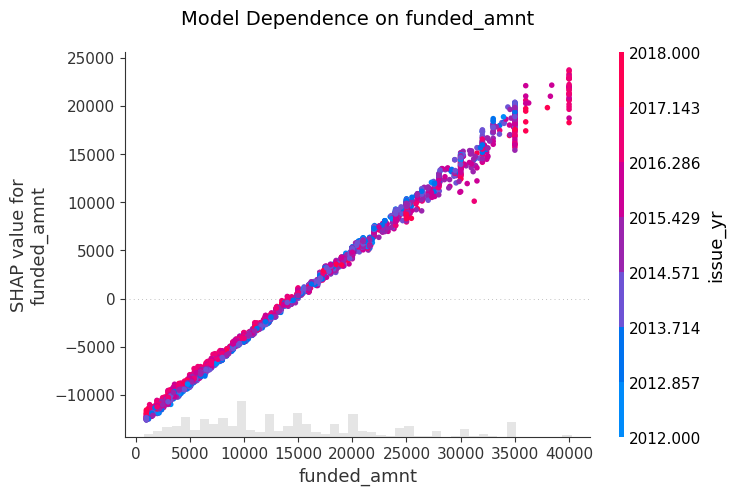

<Figure size 640x480 with 0 Axes>

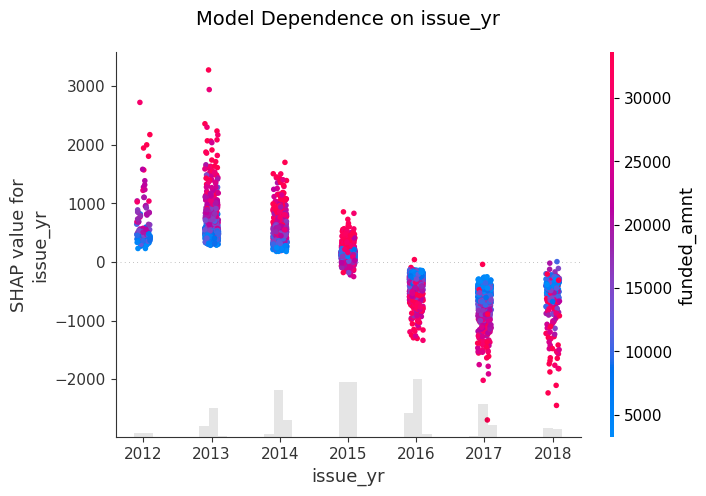

<Figure size 640x480 with 0 Axes>

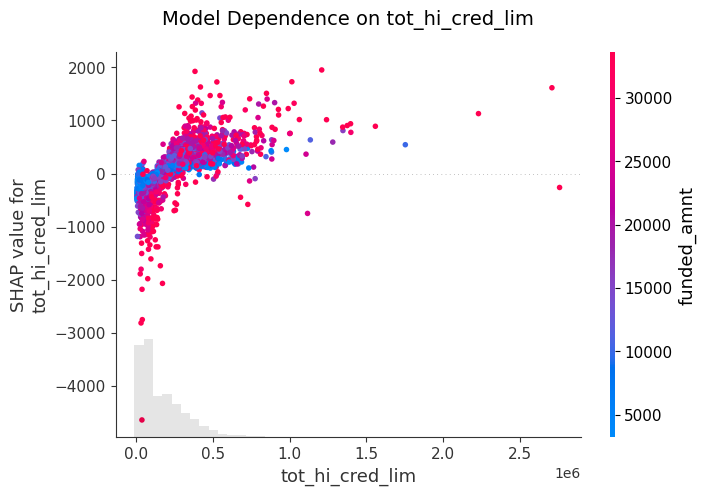

<Figure size 640x480 with 0 Axes>

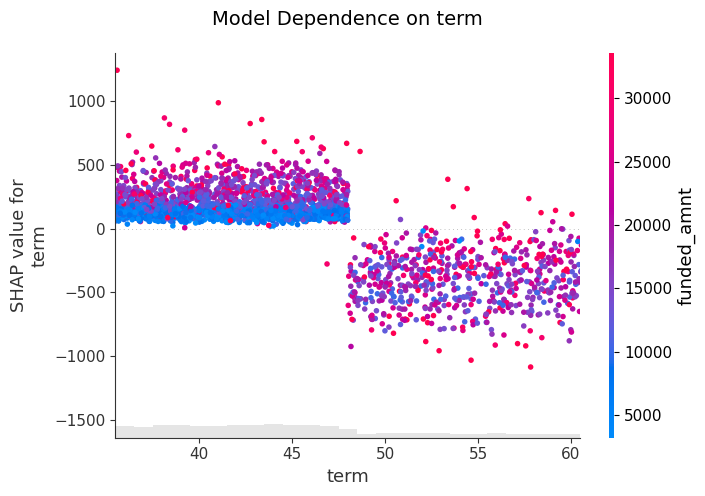

<Figure size 640x480 with 0 Axes>

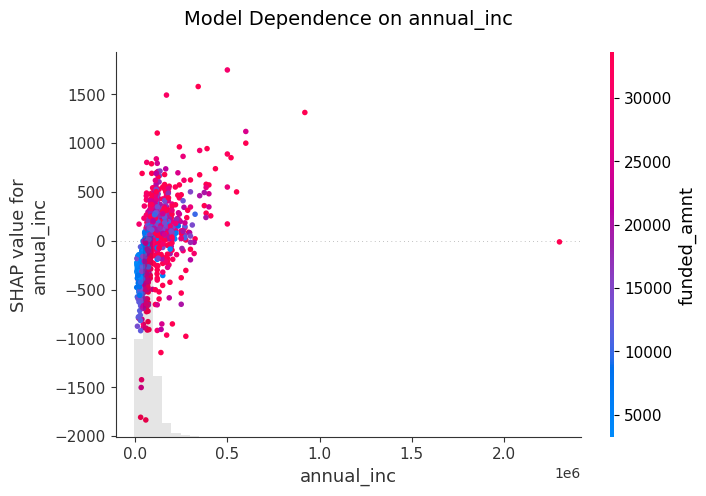

In [ ]:
top_feats = [
    "funded_amnt",
    "issue_yr",
    "tot_hi_cred_lim",
    "term",
    "annual_inc"
]

for feat in top_feats:
  plt.figure()
  shap.plots.scatter(shap_values_sample[:, feat], color=shap_values_sample, show=False)

  plt.title(f"Model Dependence on {feat}", pad=20, fontsize=14)
  plt.savefig(dir + f"shap_dependence_{feat}.png", dpi=300, bbox_inches="tight")
  plt.show()
  print("\n")

### Local Explainability Analysis

In [ ]:
# Prompt user to select pred for local explanation
pred_idx = int(input("Select a prediction to explain (e.g., 0): "))

# Prompt user to specify whether to save plot
to_save = input("Save plot? (y/n): ")

save = True if to_save.lower() == "y" else False

X_tr_df = pd.DataFrame(X_tr, columns=feat_names)

# Extract local SHAP values and feature values
local_shap_vals = shap_values[pred_idx].values
feat_vals = X_tr_df.iloc[pred_idx].values

# Extract base value
base_val = explainer.expected_value
if isinstance(base_val, np.ndarray):
  base_val = base_val[0]

# Compute final pred
final_pred = base_val + np.sum(local_shap_vals)

local_df = pd.DataFrame({
    "Feature": feat_names,
    "SHAP Value": local_shap_vals,
    "Feature Value": feat_vals,
    "Absolute Impact": np.abs(local_shap_vals)
})

# Sort by absolute impact and isolate top 10 most impactful features
local_df = local_df.sort_values(by="Absolute Impact", ascending=True).tail(10)

# Define func to format data labels
def format_val(val):
  if isinstance(val, (float, np.float64, np.float32)):
    return f"{val:.0f}"
  return str(val)

# Construct data labels
local_df["Label"] = local_df["Feature"] + " = " + local_df["Feature Value"].apply(format_val)

# Assign bar colours
local_df["Colour"] = np.where(local_df["SHAP Value"] >= 0, "#FF0D57", "#1E88E5")

fig = go.Figure()

fig.add_trace(go.Bar(
    x=local_df["SHAP Value"],
    y=local_df["Label"],
    orientation="h",
    marker=dict(color=local_df["Colour"]),
    text=local_df["SHAP Value"],
    texttemplate="%{text:$,.2f}",
    textposition="auto"
))

fig.add_vline(x=0, line_width=2, line_color="#333333")

fig.update_layout(
    title=dict(
        text=f"Local SHAP Explanation: Test Observation {pred_idx}<br><sup><i>Top 10 Most Impactful Features</i></sup>",
        subtitle=dict(text=f"Base RAR: <b>&#36;{base_val:,.2f}</b> | Predicted RAR: <b>&#36;{final_pred:,.2f}</b>")
    ),
    xaxis_title="SHAP Value (Impact on RAR)",
    yaxis_title="",
    template="plotly_white",
    font=dict(family="Helvetica Neue, sans-serif", color="#666666"),
    width=900,
    height=600,
    margin=dict(l=200)
)

fig.update_xaxes(tickformat="$~s")

if save:
    fig.write_image(dir + f"shap_local_custom_{pred_idx}.png", scale=3)

fig.show()

Select a prediction to explain (e.g., 0): 16
Save plot? (y/n): n
